# 04 — Mejoras QWK: regresión ordinal y ensemble

Segunda iteración de modelado orientada a **maximizar QWK** (kappa cuadrático) sobre el target ordinal `sii` (0–3).

El código reproducible vive en `src/`; este notebook **documenta y visualiza** los resultados del CLI.

**Ejecutar antes:**
```
python -m src.main train
python -m src.main train-ensemble
```

Modelo final y figuras honestas para el informe (`tune`, `fit-final`, `report-oof`): ver notebook **05**.


In [19]:
%run init_notebook.py


Project root: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica
Train data:   C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\train.csv


In [20]:
from IPython.display import Image, display

from src.config import (
    CV_FOLDS,
    DROP_SEASON_COLUMNS,
    EXPECTED_MODELING_SHAPE,
    FEATURE_SELECTION_TOP_N,
    USE_ITERATIVE_IMPUTER,
    USE_SAMPLE_WEIGHTS,
)
from src.data.dataset import load_modeling_frame
from src.models.registry import ENSEMBLE_REGRESSION_MODELS

print(f"Results dir: {RESULTS_DIR}")
print(f"CV folds: {CV_FOLDS}")


Results dir: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\experiments\results
CV folds: 10


## 1. Cambios en datos y preprocesamiento

- Filas etiquetadas: **2736** (sin imputar `sii` nulo).
- Columnas tras limpieza: **46** (features derivadas, sin columnas `*-Season`).
- Imputación numérica: `IterativeImputer`.
- Validación cruzada estratificada: **10 folds**.
- Selección opcional top-N features si existe `permutation_importance_oof.csv` (generado por `report-oof`).


In [21]:
df_model = load_modeling_frame()
print(f"Shape modeling frame: {df_model.shape} (esperado {EXPECTED_MODELING_SHAPE})")
print(f"DROP_SEASON_COLUMNS={DROP_SEASON_COLUMNS}")
print(f"USE_ITERATIVE_IMPUTER={USE_ITERATIVE_IMPUTER}")
print(f"USE_SAMPLE_WEIGHTS={USE_SAMPLE_WEIGHTS}")
print(f"FEATURE_SELECTION_TOP_N={FEATURE_SELECTION_TOP_N}")
derived = [c for c in df_model.columns if c in ("BIA_DEE_minus_BMR", "BMI_age_ratio")]
print(f"Features derivadas presentes: {derived}")


Shape modeling frame: (2736, 46) (esperado (2736, 46))
DROP_SEASON_COLUMNS=True
USE_ITERATIVE_IMPUTER=True
USE_SAMPLE_WEIGHTS=True
FEATURE_SELECTION_TOP_N=35
Features derivadas presentes: ['BIA_DEE_minus_BMR', 'BMI_age_ratio']


## 2. Enfoque: regresión ordinal + umbrales QWK + voting

1. **Regresores** (`LGBMRegressor`, `XGBRegressor`, `ExtraTreesRegressor`) predicen `sii` continuo.
2. **`ThresholdOrdinalClassifier`** optimiza tres umbrales para maximizar QWK.
3. **`regression_vote`**: mode vote sobre clases discretizadas.
4. **Sample weights** por cuantiles de `sii`.

Código: `src/evaluation/thresholds.py`, `src/models/ensemble_regression.py`, `src/training/train_ensemble.py`.


## 3. Resultados: clasificadores vs ensemble ordinal

In [22]:
holdout_path = RESULTS_DIR / "all_models_holdout.csv"
cv_path = RESULTS_DIR / "all_models_cv.csv"

if not holdout_path.exists():
    raise FileNotFoundError(
        "Ejecuta: python -m src.main train && python -m src.main train-ensemble"
    )

holdout = pd.read_csv(holdout_path)
cv = pd.read_csv(cv_path)
ensemble_models = set(ENSEMBLE_REGRESSION_MODELS)

baseline_holdout = holdout[~holdout["model"].isin(ensemble_models)]
ensemble_holdout = holdout[holdout["model"].isin(ensemble_models)]
baseline_cv = cv[~cv["model"].isin(ensemble_models)]
ensemble_cv = cv[cv["model"].isin(ensemble_models)]

best_baseline_cv = baseline_cv.sort_values("qwk_mean", ascending=False).iloc[0]
print(
    f"Mejor baseline (CV): {best_baseline_cv['model']} "
    f"QWK={best_baseline_cv['qwk_mean']:.4f} ± {best_baseline_cv['qwk_std']:.4f}"
)

if ensemble_cv.empty:
    print("Sin filas ensemble. Ejecuta: python -m src.main train-ensemble")
else:
    best_ens = ensemble_cv.sort_values("qwk_mean", ascending=False).iloc[0]
    print(
        f"Mejor ensemble (CV): {best_ens['model']} "
        f"QWK={best_ens['qwk_mean']:.4f} ± {best_ens['qwk_std']:.4f}"
    )
    delta = float(best_ens["qwk_mean"]) - float(best_baseline_cv["qwk_mean"])
    print(f"Delta QWK CV (ensemble - baseline): {delta:+.4f}")

print("\n=== Ensemble (holdout) ===")
display(ensemble_holdout.sort_values("qwk", ascending=False))
print("\n=== Ensemble (CV) ===")
display(ensemble_cv.sort_values("qwk_mean", ascending=False))


Mejor baseline (CV): svm QWK=0.3937 ± 0.0535
Mejor ensemble (CV): lgbm_regressor QWK=0.4133 ± 0.0470
Delta QWK CV (ensemble - baseline): +0.0195

=== Ensemble (holdout) ===


,model,level,f1_macro,balanced_accuracy,qwk,accuracy
13,lgbm_regressor,advanced,0.385591,0.389112,0.426353,0.600365
12,regression_vote,advanced,0.359862,0.368243,0.388604,0.613139
10,xgb_regressor,advanced,0.357004,0.368773,0.380877,0.591241
11,extratrees_regressor,advanced,0.298183,0.309793,0.282292,0.598540



=== Ensemble (CV) ===


,model,level,qwk_mean,qwk_std,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,balanced_accuracy_std
13,lgbm_regressor,advanced,0.413265,0.046993,0.357800,0.040897,0.358158,0.033372
10,xgb_regressor,advanced,0.399136,0.045243,0.380477,0.059048,0.372593,0.043948
12,regression_vote,advanced,0.382475,0.000000,0.324915,0.000000,0.330619,0.000000
11,extratrees_regressor,advanced,0.368374,0.044396,0.331841,0.027648,0.334731,0.022204


## 4. Gráficos comparativos (holdout QWK)

1. **`model_comparison_qwk.png`** — solo clasificadores del paso `train` (primer acercamiento).
2. **`model_comparison_qwk_all.png`** — **todos** los modelos tras `train-ensemble` (aquí `lgbm_regressor` lidera).

Baseline (solo train):


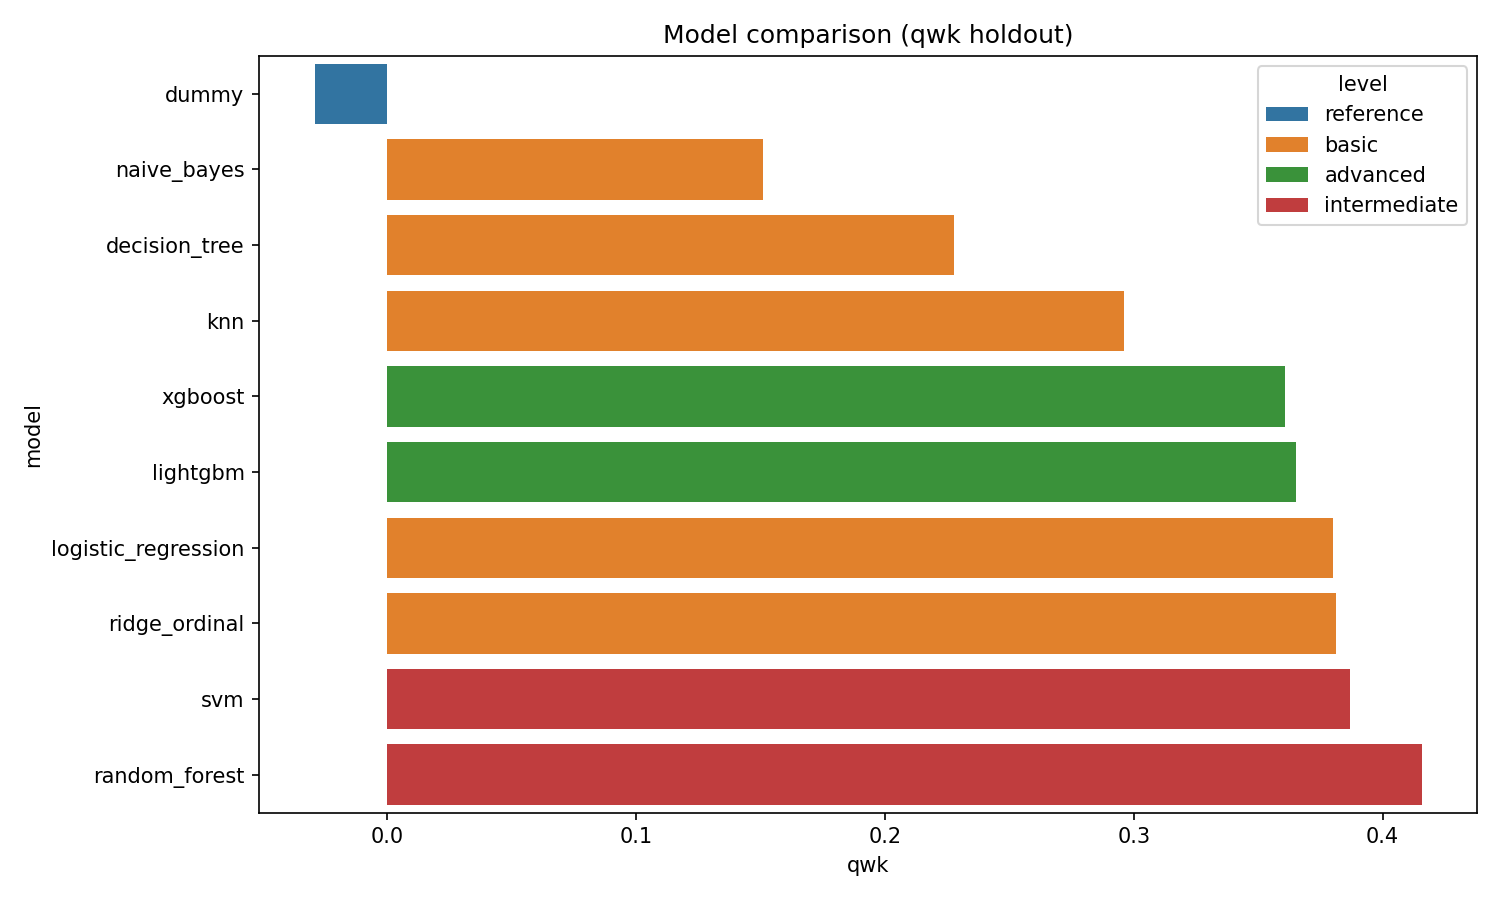

Todos los modelos (train + train-ensemble):


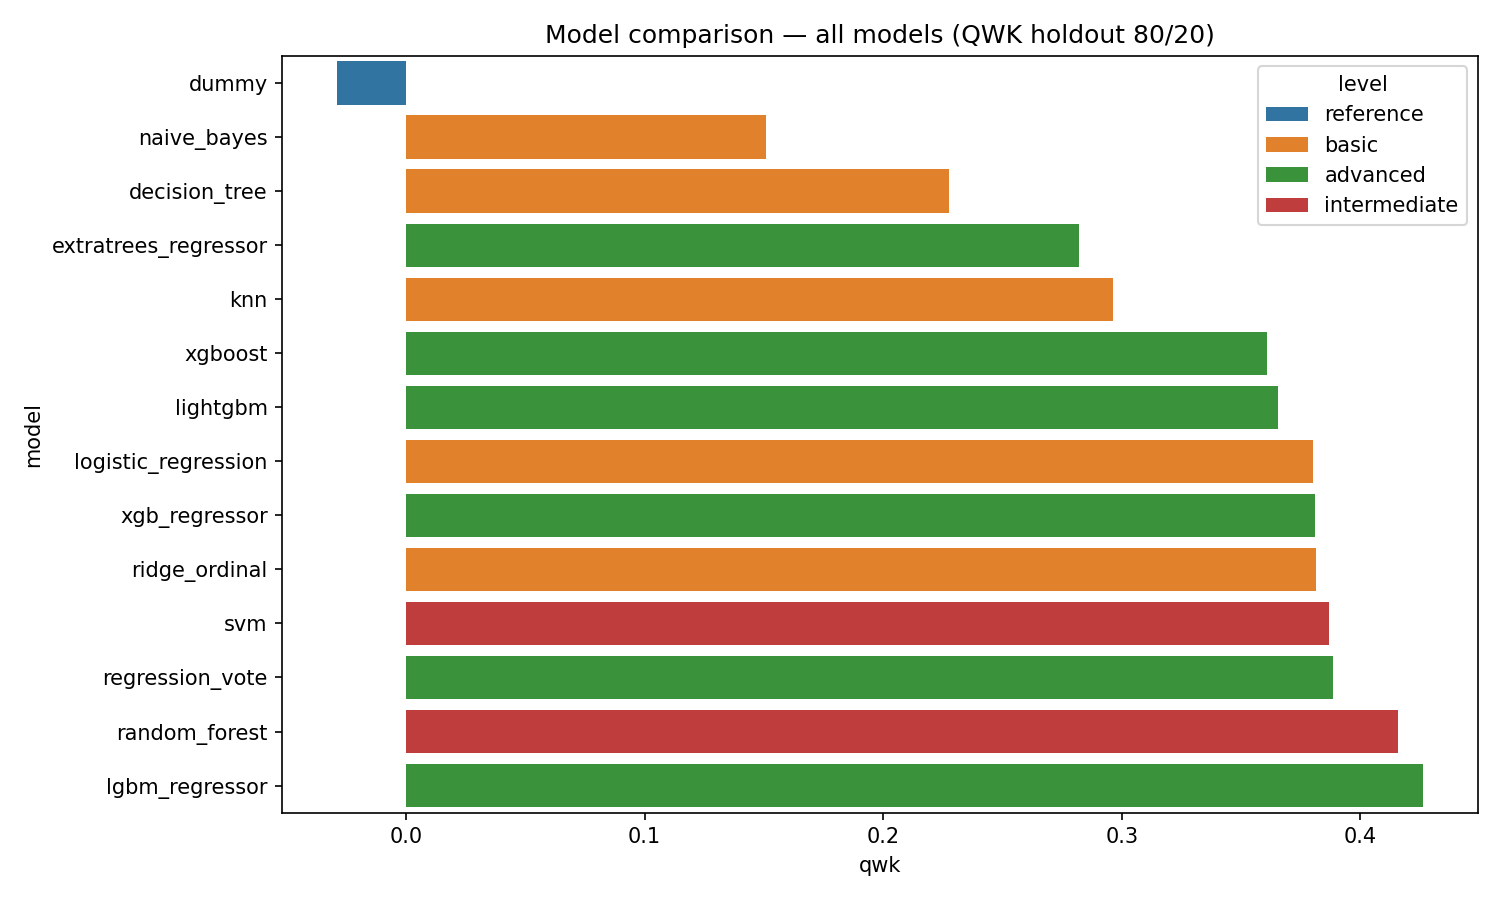

In [23]:
baseline_fig = FIGURES_DIR / "model_comparison_qwk.png"
all_fig = FIGURES_DIR / "model_comparison_qwk_all.png"

if baseline_fig.exists():
    print("Baseline (solo train):")
    display(Image(filename=str(baseline_fig)))
else:
    print(f"No encontrado: {baseline_fig} (ejecuta python -m src.main train)")

if all_fig.exists():
    print("Todos los modelos (train + train-ensemble):")
    display(Image(filename=str(all_fig)))
else:
    print(f"No encontrado: {all_fig} (ejecuta python -m src.main train-ensemble)")


## 5. Umbrales del modelo final (regresión ordinal)

Solo aplica a `lgbm_regressor`, `xgb_regressor` y `extratrees_regressor`: tres cortes que convierten la predicción continua en clases 0–3 optimizando QWK. El modelo final se elige por **CV** (`all_models_cv.csv`), no por el gráfico baseline.

In [24]:
import json

meta_path = RESULTS_DIR / "final_model_meta.json"
if meta_path.exists():
    with open(meta_path, encoding="utf-8") as f:
        meta = json.load(f)
    print(f"Modelo final: {meta.get('model')}")
    if "thresholds" in meta:
        print("Umbrales QWK:")
        print(json.dumps(meta["thresholds"], indent=2))
    else:
        print("Sin umbrales (clasificador directo).")
else:
    print("Ejecuta tune + fit-final + report-oof (ver notebook 05).")


Modelo final: lgbm_regressor
Umbrales QWK:
[
  0.9711177626411477,
  1.5173510916816946,
  2.15641662119112
]


## 6. Conclusiones

- Compare **QWK en CV** (`all_models_cv.csv`) para elegir modelos de forma honesta.
- Tras `fit-final`, use **`report-oof`** para matriz de confusión y métricas por clase (OOF 10-fold, sin fuga).
- Holdout 80/20 (`all_models_holdout.csv`) es referencia secundaria del paso `train` / `train-ensemble`.
- Clase 3 (~1.2%) limita el techo del QWK.
- Siguiente paso: notebook **05** (tuning, diseño 2+3, diagnóstico OOF).
